#NovaPlas Hogar

NovaPlas Hogar es una empresa comercializadora de productos plásticos para el hogar.

**•	Portafolio:** 1000 SKU, entre sillas, organizadores, canecas, recipientes y productos de uso doméstico.

**•	Problema Actual: ¿Qué productos deben comprarse, qué cantidades se deben solicitar y si la compra es conveniente?**

**•	Impacto:** Riesgo de desabastecimiento, sobrecostos y uso ineficiente del presupuesto.

**•	Solución propuesta:** Optimización de decisiones de compra para NovaPlas Hogar.

## 1. Cargar librerias

- `pandas` (`pd`): leer los CSV y trabajar con tablas.
- `numpy` (`np`): calculos numericos sobre arreglos.
- `matplotlib.pyplot` (`plt`): el grafico final.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 2. Cargar los 5 CSV

Estos CSV contienen toda la info para poder llegar a la solución del problema incial del proyecto.
`parametros_generales.csv`, `tiempos_entrega.csv`, `base_productos.csv`,
`historico_ventas_2025.csv`, `inventario_actual.csv`.


In [11]:
usuario_github = "LeidyV96"
nombre_repositorio = "ProyectoPAD_Analisis_Compras"
rama = "main"

url_base = f"https://raw.githubusercontent.com/LeidyV96/ProyectoPAD_Analisis_Compras/refs/heads/main/"

parametros_generales = pd.read_csv(url_base + "parametros_generales.csv")
tiempos_entrega = pd.read_csv(url_base + "tiempos_entrega.csv")
base = pd.read_csv(url_base + "base_productos.csv")
ventas = pd.read_csv(url_base + "historico_ventas_2025.csv")
inventario = pd.read_csv(url_base + "inventario_actual.csv")

base.head()


,Tipo de producto,Proveedor,SKU,Descripcion,Estado,Unidad de Empaque,Color,Alto,Ancho,Largo,Tamaño,Costo Promedio,Fecha de Ingreso
0,Nacional,COLPLAST,728623003,PLATO LLANO SURTIDO REF 003,Activo,280,INDEFINIDO,0.00,0.00,0.00,PEQUEÃ‘O,"1,131.30",2013-04-18
1,Nacional,COLPLAST,728623004,PLATO HONDO SURTIDO REF 004,Activo,280,INDEFINIDO,0.00,0.00,0.00,PEQUEÃ‘O,"1,037.32",2013-04-18
2,Nacional,COLPLAST,728623005,PLATO SUPER HONDO SURTIDO REF 005,Activo,280,INDEFINIDO,0.00,0.00,0.00,PEQUEÃ‘O,"1,261.53",2013-04-18
3,Nacional,COLPLAST,728623009,POCILLO CHOCOLATERO SURTIDO REF 009,Activo,280,INDEFINIDO,0.00,0.00,0.00,PEQUEÃ‘O,823.45,2013-04-18
4,Nacional,COLPLAST,728623018,VASO ARENADO 10 ONZAS REF 018,Activo,480,INDEFINIDO,0.00,0.00,0.00,PEQUEÃ‘O,542.77,2015-06-23


## 3. Parametros del negocio y tiempos de entrega

Los parametros (dias del mes, limite de costo, presupuesto) se leen del
CSV. El tiempo de entrega depende del proveedor, asi que definimos un
**diccionario** `{proveedor: tiempo_de_entrega}` con `dict()` y `zip()`:
esto nos deja "buscar" el tiempo de entrega de cualquier producto
conociendo solo su proveedor.


In [12]:
dias_mes = int(parametros_generales.loc[parametros_generales["Parametro"] == "Días del mes", "Valor"].iloc[0])
limite_costo = float(parametros_generales.loc[parametros_generales["Parametro"] == "Límite aumento del costo", "Valor"].iloc[0])
presupuesto = float(parametros_generales.loc[parametros_generales["Parametro"] == "Presupuesto de compras", "Valor"].iloc[0])

#
dict_tiempos_entrega = dict(zip(tiempos_entrega["Proveedor"], tiempos_entrega["Tiempo de entrega"]))

print(f"Dias del mes: {dias_mes}")
print(f"Limite de aumento de costo: {limite_costo:.0%}")
print(f"Presupuesto: ${presupuesto:,.0f}")
print(f"Tiempos de entrega: {dict_tiempos_entrega}")


Dias del mes: 30
Limite de aumento de costo: 20%
Presupuesto: $2,000,000,000
Tiempos de entrega: {'COLPLAST': 10, 'ESTRA': 20, 'KENDY': 8, 'PLESCO': 6, 'MQ': 12, 'PERSAL': 15, 'PLASTIRED': 12, 'RIMAX': 10, 'VANYPLAS': 20, 'WANTU': 25}


## 4. Limpiar la matriz de inventario

Algunas filas de `Inventario Actual` traen el texto `"#N/D"` en vez de un
numero. Con `pd.to_numeric(..., errors="coerce")` esos casos quedan como
`NaN` (vacio); con una **mascara booleana** (`.notna()`) identificamos
cuales son validos, y con `df.loc[mascara].copy()` nos quedamos solo con
esas filas.


In [ ]:
#
inventario_actual_num = pd.to_numeric(inventario["Inventario Actual"], errors="coerce")
mascara_inventario_valido = inventario_actual_num.notna()

inventario_valido = inventario.loc[mascara_inventario_valido].copy()
inventario_valido["Inventario Actual"] = inventario_actual_num.loc[mascara_inventario_valido]
inventario_valido["Pedidos pendientes"] = pd.to_numeric(
    inventario_valido["Pedidos pendientes"], errors="coerce"
).fillna(0)
inventario_valido["Stock de seguridad"] = pd.to_numeric(
    inventario_valido["Stock de seguridad"], errors="coerce"
)

print(f"Productos con inventario valido: {mascara_inventario_valido.sum()}")
#
print(f"Productos excluidos (dato invalido): {(~mascara_inventario_valido).sum()}")


Productos con inventario valido: 986
Productos excluidos (dato invalido): 14


## 5. Venta mensual promedio de cada producto

Tomamos las ventas de los 12 meses, las convertimos a un array con `.to_numpy()` (queda una matriz de 1000 productos x 12 meses) y calculamos
el promedio **por fila** (`axis=1`): un promedio por producto.


In [ ]:

#listas en comprension
columnas_meses = [c for c in ventas.columns if c not in ("SKU", "Descripcion")]

matriz_ventas = ventas[columnas_meses].to_numpy()

venta_mensual = matriz_ventas.mean(axis=1)   # promedio por producto (por fila)
print("Venta mensual promedio (primeros 5 productos):", venta_mensual[:5])


Venta mensual promedio (primeros 5 productos): [ 350.5         499.91666667   76.         1040.08333333 1639.08333333]


## 6. Unir todo en una sola tabla

In [ ]:
tabla = base.merge(
    pd.DataFrame({"SKU": ventas["SKU"], "venta_mensual": venta_mensual}),
    on="SKU",
)
tabla = tabla.merge(
    inventario_valido[["SKU", "Inventario Actual", "Pedidos pendientes", "Stock de seguridad", "Costo actual"]],
    on="SKU",
)
tabla["tiempo_entrega"] = tabla["Proveedor"].map(dict_tiempos_entrega)

print(f"SKU en la tabla final: {len(tabla)} de {len(base)}")
tabla.head()


SKU en la tabla final: 986 de 1000


,Tipo de producto,Proveedor,SKU,Descripcion,Estado,Unidad de Empaque,Color,Alto,Ancho,Largo,Tamaño,Costo Promedio,Fecha de Ingreso,venta_mensual,Inventario Actual,Pedidos pendientes,Stock de seguridad,Costo actual,tiempo_entrega
0,Nacional,COLPLAST,728623003,PLATO LLANO SURTIDO REF 003,Activo,280,INDEFINIDO,0.00,0.00,0.00,PEQUEÃ‘O,"1,131.30",2013-04-18,350.50,"1,224.00",0.00,525.75,"1,131.30",10
1,Nacional,COLPLAST,728623004,PLATO HONDO SURTIDO REF 004,Activo,280,INDEFINIDO,0.00,0.00,0.00,PEQUEÃ‘O,"1,037.32",2013-04-18,499.92,487.00,560.00,749.88,"1,037.32",10
2,Nacional,COLPLAST,728623005,PLATO SUPER HONDO SURTIDO REF 005,Activo,280,INDEFINIDO,0.00,0.00,0.00,PEQUEÃ‘O,"1,261.53",2013-04-18,76.00,205.00,560.00,114.00,"1,261.53",10
3,Nacional,COLPLAST,728623009,POCILLO CHOCOLATERO SURTIDO REF 009,Activo,280,INDEFINIDO,0.00,0.00,0.00,PEQUEÃ‘O,823.45,2013-04-18,"1,040.08",212.00,840.00,"1,560.12",823.45,10
4,Nacional,COLPLAST,728623018,VASO ARENADO 10 ONZAS REF 018,Activo,480,INDEFINIDO,0.00,0.00,0.00,PEQUEÃ‘O,542.77,2015-06-23,"1,639.08",550.00,480.00,"2,458.62",542.77,10


## 7. Corregir Stock de seguridad inusual

Si el stock de seguridad de un producto representa **mas de 300 veces su
demanda** durante el tiempo de entrega, lo tratamos como un dato erroneo y
lo llevamos a 0. Se calcula con `np.where` y una mascara booleana.


In [ ]:
venta_diaria = tabla["venta_mensual"].to_numpy() / dias_mes
demanda = venta_diaria * tabla["tiempo_entrega"].to_numpy()
stock_seguridad = tabla["Stock de seguridad"].to_numpy()

razon_stock_demanda = np.zeros(len(tabla))
mascara_demanda_positiva = demanda > 0
razon_stock_demanda[mascara_demanda_positiva] = (
    stock_seguridad[mascara_demanda_positiva] / demanda[mascara_demanda_positiva]
)

#histograma o gráfico de cajas de razon stock demanda
razon_stock_demanda.describe()


NameError: name 'tabla' is not defined

In [ ]:


mascara_stock_atipico = razon_stock_demanda > 300
print("SKU con Stock de seguridad atipico (se corrigen a 0):", mascara_stock_atipico.sum())

stock_seguridad_corregido = np.where(mascara_stock_atipico, 0, stock_seguridad)
stock_seguridad_corregido = np.where(np.isnan(stock_seguridad_corregido), 0, stock_seguridad_corregido)
tabla["Stock de seguridad"] = stock_seguridad_corregido


## 8. Calcular necesidad de compra

Un producto se recomienda solo si necesita compra **y** es conveniente en costo.


In [ ]:
def diferencia_porcentual_costo(costo_actual, costo_promedio):
    #Cuanto por ciento mas caro esta el costo actual frente al promedio.
    return (costo_actual - costo_promedio) / costo_promedio * 100


def cantidad_en_empaques(cantidad_necesaria, unidad_empaque):
    #Redondea hacia arriba una cantidad al multiplo de empaque mas cercano.
    return np.ceil(cantidad_necesaria / unidad_empaque) * unidad_empaque


In [ ]:
inventario_actual_arr = tabla["Inventario Actual"].to_numpy()
pedidos_arr = tabla["Pedidos pendientes"].to_numpy()
stock_seguridad_arr = tabla["Stock de seguridad"].to_numpy()
costo_actual_arr = tabla["Costo actual"].to_numpy()
costo_promedio_arr = tabla["Costo Promedio"].to_numpy()
empaque_arr = tabla["Unidad de Empaque"].to_numpy()

punto_reorden = demanda + stock_seguridad_arr
inv_proyectado = inventario_actual_arr + pedidos_arr
dif_inventario = punto_reorden - inv_proyectado
dif_porcentual = diferencia_porcentual_costo(costo_actual_arr, costo_promedio_arr)

mascara_necesita_compra = dif_inventario > 0
mascara_costo_conveniente = dif_porcentual <= (limite_costo * 100)
mascara_recomendado = mascara_necesita_compra & mascara_costo_conveniente

print("Necesitan compra:", mascara_necesita_compra.sum())
print("Recomendados (necesita compra y es conveniente):", mascara_recomendado.sum())


Necesitan compra: 188
Recomendados (necesita compra y es conveniente): 188


In [ ]:
# np.zeros: reservamos el array de cantidad sugerida en 0,
# y solo lo llenamos donde si se recomienda comprar
cantidad_sugerida = np.zeros(len(tabla))
cantidad_sugerida[mascara_recomendado] = cantidad_en_empaques(
    dif_inventario[mascara_recomendado], empaque_arr[mascara_recomendado]
)
costo_compra = cantidad_sugerida * costo_actual_arr

tabla["dif_inventario"] = dif_inventario
tabla["punto_reorden"] = punto_reorden
tabla["cant_sugerida"] = cantidad_sugerida
tabla["costo_compra"] = costo_compra

#
tabla["Estado_compra"] = np.where(mascara_recomendado, "Comprar", "No comprar")

print(f"Costo total si se compra todo lo recomendado: ${costo_compra[mascara_recomendado].sum():,.0f}")


Costo total si se compra todo lo recomendado: $200,309,681


## 9. Priorizar por presupuesto

Con `df.loc[mascara].copy()` nos quedamos solo con los productos
recomendados. El % de **urgencia** de cada uno es que tan grande es su faltante
frente a su propio punto de reorden; ordenamos de mas a menos urgente, y
vamos sumando el costo (`.cumsum()`) hasta donde alcance el presupuesto.


In [ ]:
columnas_reporte = ("SKU", "Descripcion", "Proveedor", "cant_sugerida", "costo_compra")

recomendados = tabla.loc[mascara_recomendado].copy()
recomendados["urgencia"] = np.where(
    recomendados["punto_reorden"] > 0,
    recomendados["dif_inventario"] / recomendados["punto_reorden"],
    0,
)
recomendados = recomendados.sort_values("urgencia", ascending=False)
recomendados["costo_acumulado"] = recomendados["costo_compra"].cumsum()

mascara_aprobado = recomendados["costo_acumulado"] <= presupuesto
aprobados = recomendados.loc[mascara_aprobado].copy()

print(f"Productos recomendados en total: {len(recomendados)}")
print(f"Productos aprobados dentro del presupuesto: {len(aprobados)}")
print(f"Costo total aprobado: ${aprobados['costo_compra'].sum():,.0f}")

aprobados[list(columnas_reporte)].head(10)


Productos recomendados en total: 188
Productos aprobados dentro del presupuesto: 188
Costo total aprobado: $200,309,681


,SKU,Descripcion,Proveedor,cant_sugerida,costo_compra
216,243798052,CANECA - PAPELERA ESTRABINS PEDAL 44L NEGRO NO...,ESTRA,32.00,"3,252,561.60"
15,728623103,SILLA LIBERTY CON BRAZOS - BLANCO REF 103,COLPLAST,125.00,"2,230,466.04"
441,14338010,COLADOR KENDY NEWMINI,PLESCO,150.00,"252,782.34"
600,456131212,BOTELLA PET CON CORREA 500 ML,PERSAL,32.00,"230,400.00"
953,800132479,BOTELLA ZIU MICKEY BC-PR-300.MK1,WANTU,48.00,"404,804.35"
143,243706879,RECIP PLUS REDON 3.25L BLANCO REF 4-1001816,ESTRA,72.00,"464,526.03"
944,334182410,CEPILLO REF. 95 VANYASEO REF. 82410,VANYPLAS,"1,692.00","6,702,699.80"
800,515208016,(S)ESTANTERIA VENTILADA 5 NIVELES 18 PULG NEGR...,RIMAX,11.00,"1,810,205.31"
512,729445147,CAJONERO 3 NIVELES 263-BLA,MQ,24.00,"261,200.67"
487,729445030,TABLA MEDIANA 164-BLA,MQ,156.00,"1,931,467.47"


## 10. Resultados agregados

In [ ]:
costos_aprobados = aprobados["costo_compra"].to_numpy()

print("Suma total aprobada:  ", f"${costos_aprobados.sum():,.0f}")
print("Promedio por producto:", f"${costos_aprobados.mean():,.0f}")
print("Compra mas grande:    ", f"${costos_aprobados.max():,.0f}")
print("Desviacion estandar:  ", f"${costos_aprobados.std():,.0f}")

resumen_proveedor = aprobados.groupby("Proveedor")["costo_compra"].sum().sort_values(ascending=False)
print("\nTotal aprobado por proveedor:")
print(resumen_proveedor)


Suma total aprobada:   $200,309,681
Promedio por producto: $1,065,477
Compra mas grande:     $18,916,422
Desviacion estandar:   $2,251,009

Total aprobado por proveedor:
Proveedor
COLPLAST   75,797,708.00
RIMAX      41,694,337.51
PERSAL     17,956,084.87
ESTRA      15,262,674.97
MQ         15,233,206.36
KENDY      14,929,992.87
VANYPLAS   14,593,842.15
PLESCO      3,875,206.20
WANTU         966,627.89
Name: costo_compra, dtype: float64


## 11. Grafico de torta: compras aprobadas por proveedor

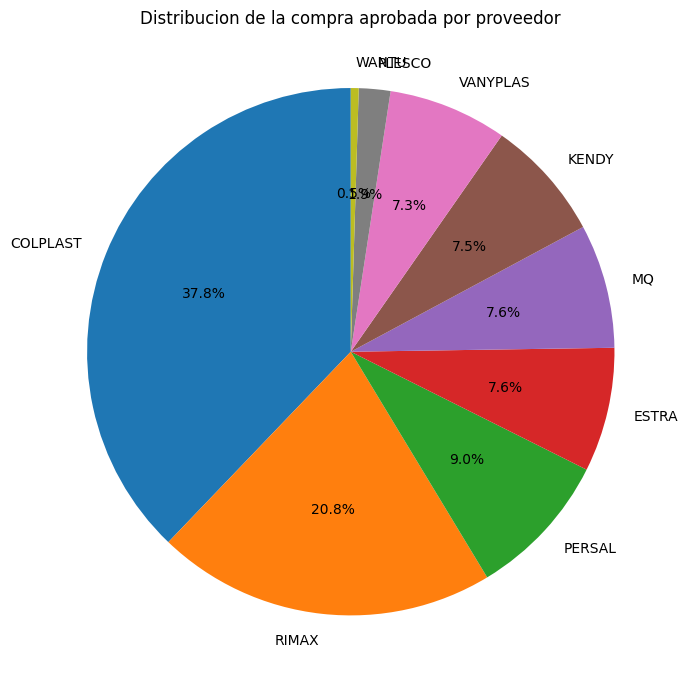

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    resumen_proveedor.values,
    labels=resumen_proveedor.index,
    autopct="%1.1f%%",
    startangle=90,
)
ax.set_title("Distribucion de la compra aprobada por proveedor")
ax.axis("equal")
plt.tight_layout()
plt.savefig("distribucion_compra_por_proveedor.png", dpi=150)
plt.show()


## 12. Exportar la solucion a Excel y descargarla

Este documento cuenta con tres hojas: la compra aprobada, el resumen por proveedor, y la tabla completa con el estado de cada SKU.

In [ ]:
nombre_archivo = "reporte_compras_novaplas.xlsx"

with pd.ExcelWriter(nombre_archivo, engine="openpyxl") as writer:
    aprobados[list(columnas_reporte) + ["urgencia", "costo_acumulado"]].to_excel(
        writer, sheet_name="Compra aprobada", index=False
    )
    resumen_proveedor.reset_index().rename(columns={"costo_compra": "Costo total aprobado"}).to_excel(
        writer, sheet_name="Resumen por proveedor", index=False
    )
    tabla[["SKU", "Descripcion", "Proveedor", "Inventario Actual", "punto_reorden",
           "dif_inventario", "cant_sugerida", "costo_compra", "Estado_compra"]].to_excel(
        writer, sheet_name="Todos los productos", index=False
    )

print(f"Archivo generado: {nombre_archivo}")

if en_colab:
    from google.colab import files
    files.download(nombre_archivo)
else:
    print("Fuera de Colab: el archivo quedo guardado en la carpeta actual del notebook.")


Archivo generado: solucion_compras_novaplas.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>